In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [483]:
df = pd.read_csv('heart.csv')

In [484]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [485]:
corr_matrix = df.corr()

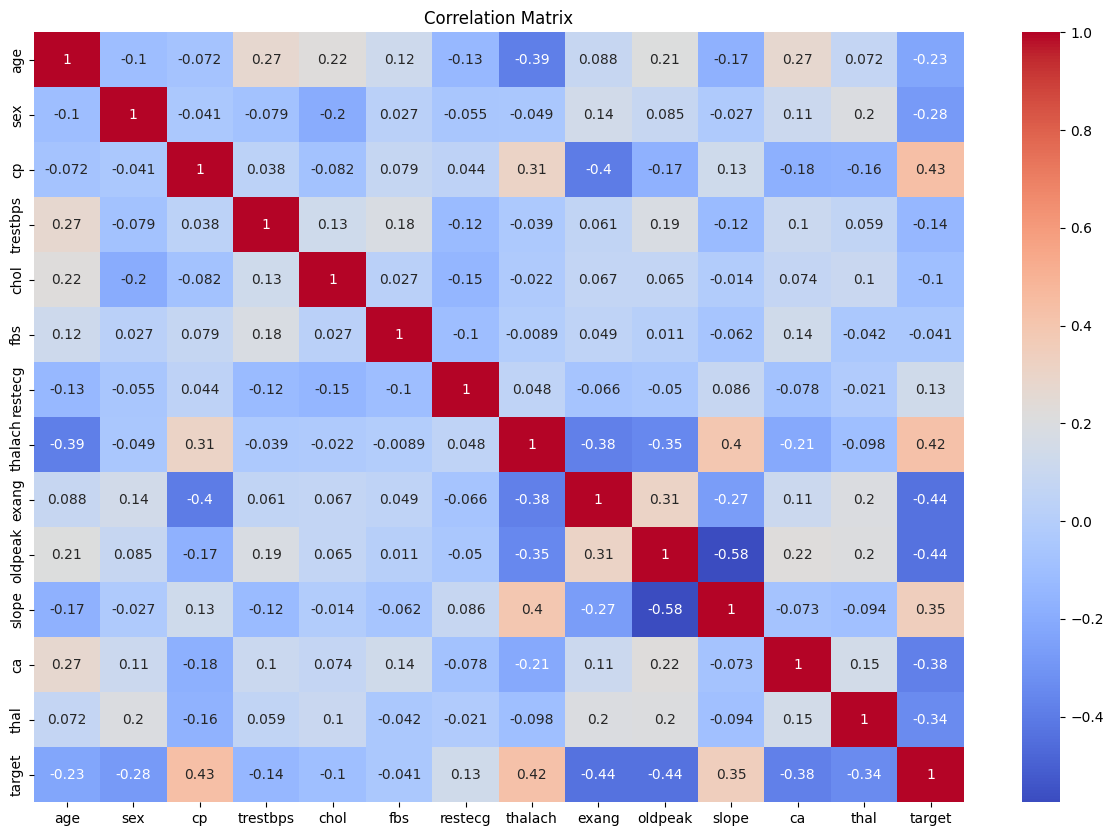

In [486]:
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## We don't need sex as it has no significance in predicting the target

In [487]:
df.drop('sex',axis=1,inplace=True)

In [488]:
## Independent Features 
X = df.drop('target',axis=1)

In [489]:
## Dependent Features
y = df['target']

In [490]:
X.isnull().sum()

age         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

In [491]:
from sklearn.model_selection import train_test_split

In [492]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [493]:
from sklearn.tree import DecisionTreeClassifier

In [494]:
dtc = DecisionTreeClassifier()

In [495]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

[Text(0.4872787610619469, 0.9545454545454546, 'x[1] <= 0.5\ngini = 0.499\nsamples = 768\nvalue = [367, 401]'),
 Text(0.22566371681415928, 0.8636363636363636, 'x[10] <= 0.5\ngini = 0.378\nsamples = 368\nvalue = [275, 93]'),
 Text(0.3564712389380531, 0.9090909090909092, 'True  '),
 Text(0.13274336283185842, 0.7727272727272727, 'x[11] <= 2.5\ngini = 0.499\nsamples = 162\nvalue = [77, 85]'),
 Text(0.05309734513274336, 0.6818181818181818, 'x[6] <= 119.5\ngini = 0.338\nsamples = 93\nvalue = [20, 73]'),
 Text(0.035398230088495575, 0.5909090909090909, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.07079646017699115, 0.5909090909090909, 'x[7] <= 0.5\ngini = 0.283\nsamples = 88\nvalue = [15.0, 73.0]'),
 Text(0.035398230088495575, 0.5, 'x[3] <= 316.5\ngini = 0.067\nsamples = 58\nvalue = [2, 56]'),
 Text(0.017699115044247787, 0.4090909090909091, 'gini = 0.0\nsamples = 55\nvalue = [0, 55]'),
 Text(0.05309734513274336, 0.4090909090909091, 'x[8] <= 0.6\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'

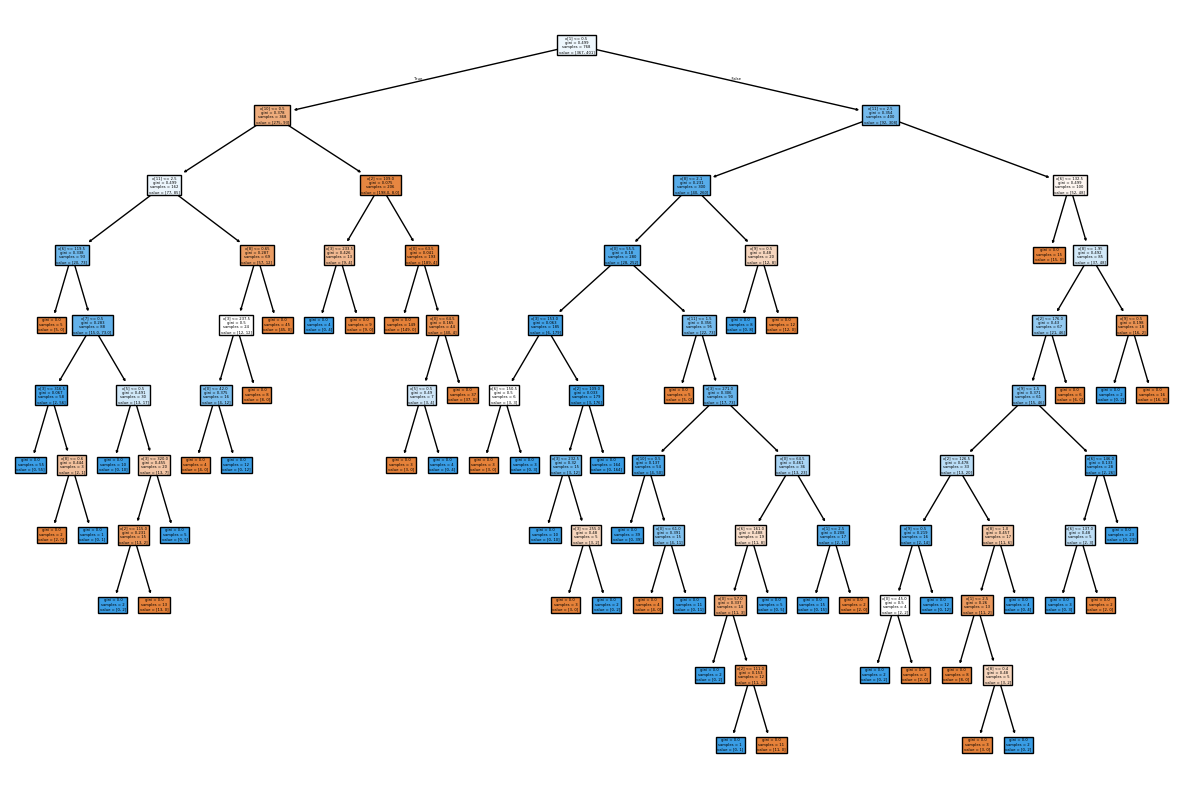

In [496]:
## Visualize Decision tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc,filled=True)

In [497]:
y_pred = dtc.predict(X_test)

In [498]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [499]:
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       132
           1       1.00      0.95      0.98       125

    accuracy                           0.98       257
   macro avg       0.98      0.98      0.98       257
weighted avg       0.98      0.98      0.98       257

0.9766536964980544
[[132   0]
 [  6 119]]


## Hyperparameter Tunning 

In [500]:
from sklearn.model_selection import GridSearchCV

In [501]:
params ={
    'criterion' : ['gini','entropy','log_loss'],
    'splitter' : ['best','random'],
    'max_depth' :[1,2,3,4,5,6,7,8,9,10],
    'max_features' :['auto','sqrt','log2'],
}

In [502]:
gcv = GridSearchCV(estimator=dtc,param_grid=params,cv=10,scoring='accuracy')

In [503]:
import warnings
warnings.filterwarnings('ignore')
gcv.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [504]:
gcv.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features='sqrt')

In [505]:
gcv.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'splitter': 'best'}

[Text(0.6137152777777778, 0.9545454545454546, 'x[7] <= 0.5\nentropy = 0.999\nsamples = 768\nvalue = [367, 401]'),
 Text(0.3454861111111111, 0.8636363636363636, 'x[9] <= 1.5\nentropy = 0.915\nsamples = 509\nvalue = [168, 341]'),
 Text(0.4796006944444444, 0.9090909090909092, 'True  '),
 Text(0.1701388888888889, 0.7727272727272727, 'x[11] <= 2.5\nentropy = 1.0\nsamples = 226\nvalue = [111, 115]'),
 Text(0.10416666666666667, 0.6818181818181818, 'x[10] <= 1.5\nentropy = 0.859\nsamples = 131\nvalue = [37, 94]'),
 Text(0.05555555555555555, 0.5909090909090909, 'x[8] <= 0.8\nentropy = 0.625\nsamples = 109\nvalue = [17, 92]'),
 Text(0.027777777777777776, 0.5, 'x[10] <= 0.5\nentropy = 0.208\nsamples = 61\nvalue = [2, 59]'),
 Text(0.013888888888888888, 0.4090909090909091, 'entropy = 0.0\nsamples = 48\nvalue = [0, 48]'),
 Text(0.041666666666666664, 0.4090909090909091, 'x[1] <= 1.5\nentropy = 0.619\nsamples = 13\nvalue = [2, 11]'),
 Text(0.027777777777777776, 0.3181818181818182, 'entropy = 0.0\nsamp

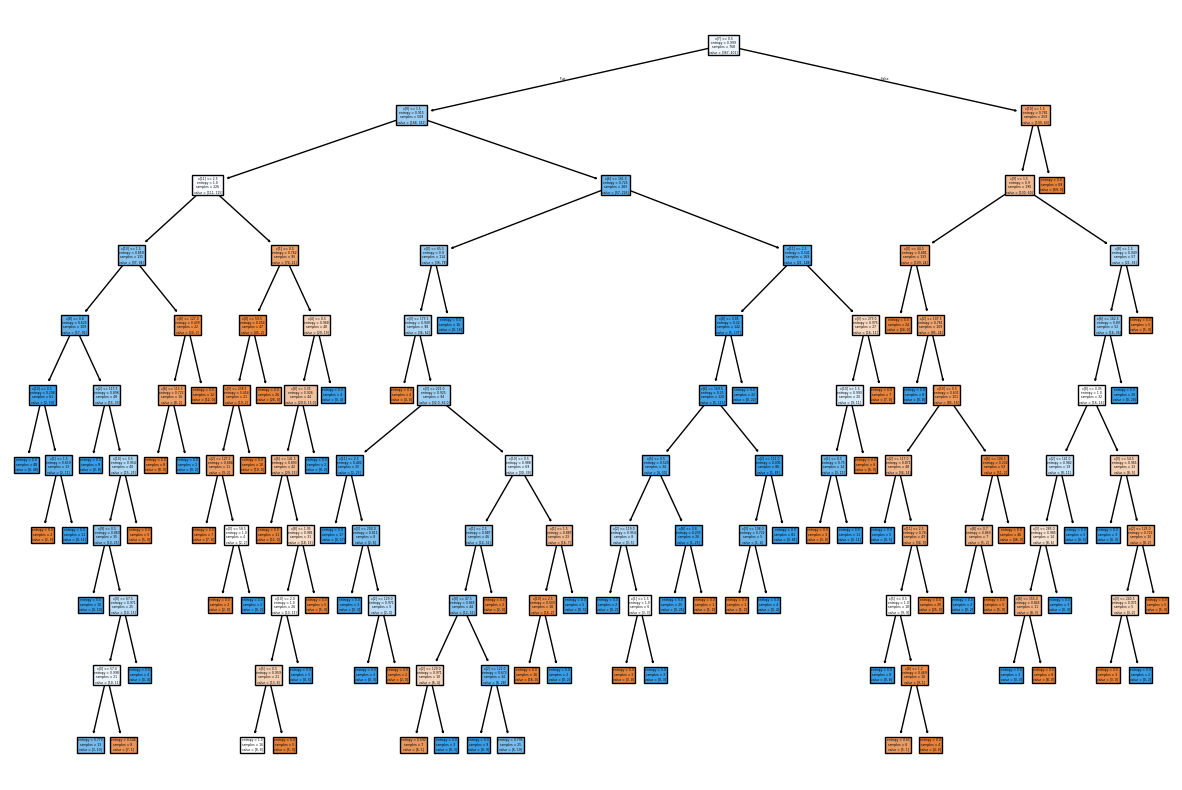

In [506]:
## Visualize Decision tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(gcv.best_estimator_,filled=True)

In [507]:
y_pred1 = gcv.predict(X_test)

In [508]:
print(classification_report(y_test,y_pred1))
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       132
           1       0.98      0.88      0.93       125

    accuracy                           0.93       257
   macro avg       0.94      0.93      0.93       257
weighted avg       0.94      0.93      0.93       257

0.933852140077821
[[130   2]
 [ 15 110]]


In [509]:
from sklearn.model_selection import RandomizedSearchCV

In [510]:
rcv = RandomizedSearchCV(estimator=dtc,param_distributions=params,cv=10,scoring='accuracy')

In [511]:
rcv.fit(X_train,y_train)

RandomizedSearchCV(cv=10, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'splitter': ['best', 'random']},
                   scoring='accuracy')

In [512]:
rcv.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_depth=9, max_features='sqrt',
                       splitter='random')

In [513]:
rcv.best_params_

{'splitter': 'random',
 'max_features': 'sqrt',
 'max_depth': 9,
 'criterion': 'log_loss'}

[Text(0.5534137228260869, 0.95, 'x[11] <= 2.549\nlog_loss = 0.999\nsamples = 768\nvalue = [367, 401]'),
 Text(0.3350883152173913, 0.85, 'x[7] <= 0.664\nlog_loss = 0.842\nsamples = 462\nvalue = [125, 337]'),
 Text(0.44425101902173914, 0.8999999999999999, 'True  '),
 Text(0.14300271739130435, 0.75, 'x[9] <= 0.687\nlog_loss = 0.693\nsamples = 360\nvalue = [67, 293]'),
 Text(0.03260869565217391, 0.65, 'x[6] <= 166.602\nlog_loss = 0.828\nsamples = 23\nvalue = [6, 17]'),
 Text(0.021739130434782608, 0.55, 'x[1] <= 1.618\nlog_loss = 0.937\nsamples = 17\nvalue = [6, 11]'),
 Text(0.010869565217391304, 0.45, 'log_loss = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.03260869565217391, 0.45, 'log_loss = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.043478260869565216, 0.55, 'log_loss = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.25339673913043476, 0.65, 'x[8] <= 1.707\nlog_loss = 0.682\nsamples = 337\nvalue = [61, 276]'),
 Text(0.12635869565217392, 0.55, 'x[1] <= 0.59\nlog_loss = 0.554\nsamples = 303

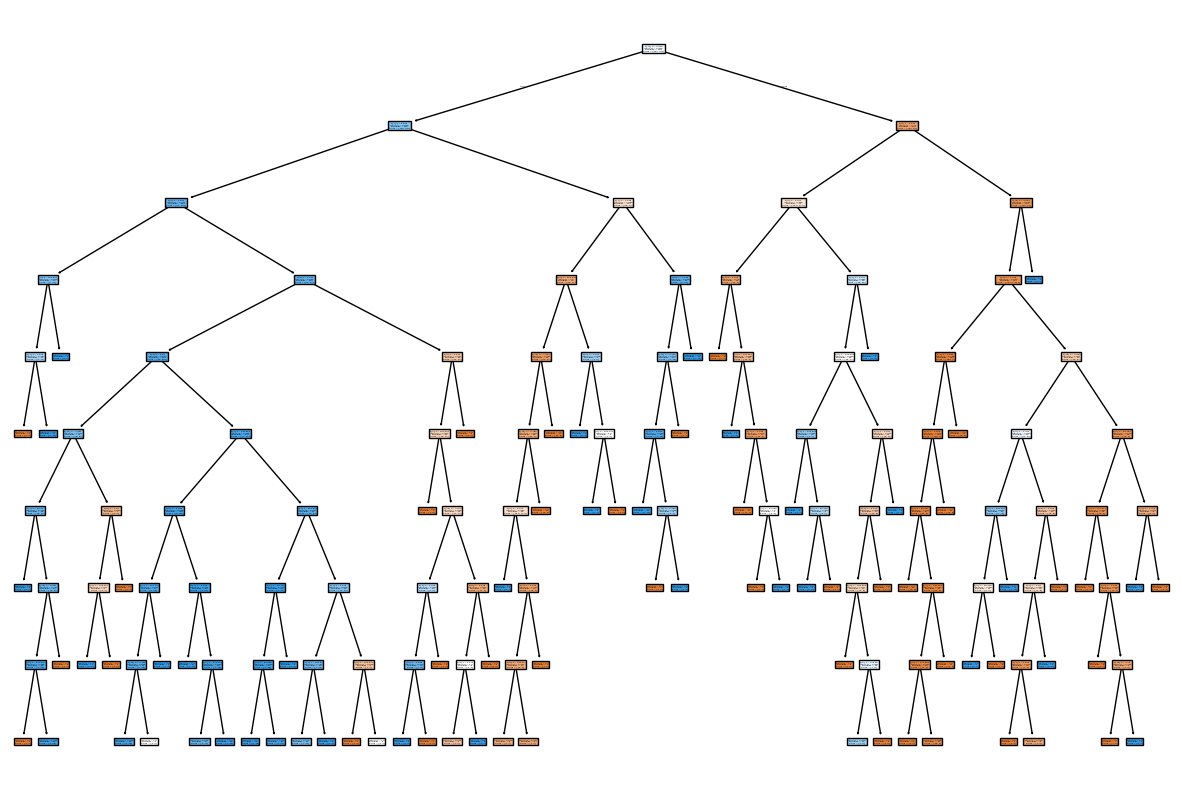

In [514]:
## Visualize Decision tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(rcv.best_estimator_,filled=True)

In [515]:
y_pred2 = rcv.predict(X_test)

In [516]:
print(classification_report(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       132
           1       0.90      0.89      0.89       125

    accuracy                           0.89       257
   macro avg       0.89      0.89      0.89       257
weighted avg       0.89      0.89      0.89       257

0.8949416342412452
[[119  13]
 [ 14 111]]


## Decision Tree Regressor

In [517]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [518]:
dtr = DecisionTreeRegressor()

In [519]:
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

In [520]:
y_pred3 = dtr.predict(X_test)

In [540]:
print(r2_score(y_test,y_pred3))
print(mean_absolute_error(y_test,y_pred3))
print(mean_squared_error(y_test,y_pred3))

0.9065454545454545
0.023346303501945526
0.023346303501945526


In [530]:
params1 ={
    'criterion' : ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'splitter' : ['best','random'],
    'max_depth' :[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    'max_features' :['auto','sqrt','log2'],
}

In [531]:
gcv1 = GridSearchCV(estimator=dtr,param_grid=params1,cv=10,scoring='accuracy')

In [532]:
gcv1.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [534]:
gcv1.best_estimator_

DecisionTreeRegressor(criterion='friedman_mse', max_depth=14,
                      max_features='sqrt')

In [535]:
gcv1.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 14,
 'max_features': 'sqrt',
 'splitter': 'best'}

[Text(0.5378521126760564, 0.9666666666666667, 'x[11] <= 2.5\nfriedman_mse = 0.25\nsamples = 768\nvalue = 0.522'),
 Text(0.2623239436619718, 0.9, 'x[1] <= 0.5\nfriedman_mse = 0.197\nsamples = 462\nvalue = 0.729'),
 Text(0.4000880281690141, 0.9333333333333333, 'True  '),
 Text(0.11619718309859155, 0.8333333333333334, 'x[6] <= 120.0\nfriedman_mse = 0.249\nsamples = 162\nvalue = 0.475'),
 Text(0.10211267605633803, 0.7666666666666667, 'friedman_mse = 0.0\nsamples = 30\nvalue = 0.0'),
 Text(0.13028169014084506, 0.7666666666666667, 'x[7] <= 0.5\nfriedman_mse = 0.243\nsamples = 132\nvalue = 0.583'),
 Text(0.06338028169014084, 0.7, 'x[9] <= 0.5\nfriedman_mse = 0.192\nsamples = 81\nvalue = 0.741'),
 Text(0.04929577464788732, 0.6333333333333333, 'friedman_mse = 0.0\nsamples = 6\nvalue = 0.0'),
 Text(0.07746478873239436, 0.6333333333333333, 'x[6] <= 152.0\nfriedman_mse = 0.16\nsamples = 75\nvalue = 0.8'),
 Text(0.028169014084507043, 0.5666666666666667, 'x[8] <= 1.8\nfriedman_mse = 0.06\nsamples = 

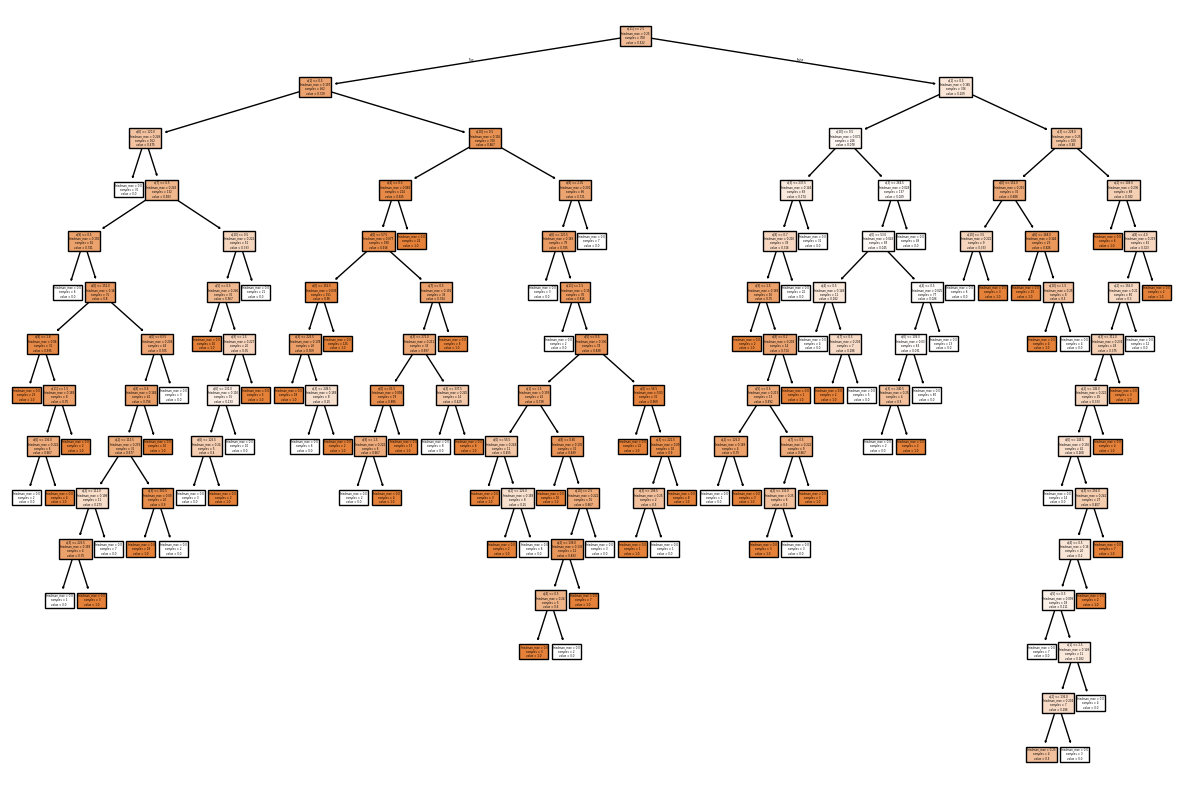

In [536]:
## Visualize Decision tree
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(gcv1.best_estimator_,filled=True)

In [537]:
y_pred4 = gcv1.predict(X_test)

In [539]:
print(r2_score(y_test,y_pred4))
print(mean_absolute_error(y_test,y_pred4))
print(mean_squared_error(y_test,y_pred4))

0.9415909090909091
0.017509727626459144
0.014591439688715954
